# Exercício

In [185]:
import datasets
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn import metrics

#### Importação do conjunto de Teste
- Importação do conjunto de teste
- Inclusão dos títulos das colunas
- Conversão das variáveis textuais

In [186]:
income = datasets.load_income_train()
income_test = datasets.load_income_test()

clf = DecisionTreeClassifier(random_state=1)
clf.fit(income.data, income.target)

DecisionTreeClassifier(random_state=1)

#### Testando a precisão do modelo

Agora que nos treinamos o modelo, podemos fazer previsões.

- É preciso dividir os dados em conjuntos de treinamento e testes primeiro.
- Se não o fizermos, estaremos fazendo previsões sobre os mesmos dados com os quais treinamos nosso algoritmo.
- Isso leva a 'overfit', e fará com que nosso erro pareça mais baixo do que é.

Precisamos, então, dividir nossos dados em conjuntos de treinamento e testes primeiro.

In [187]:
predictions = clf.predict(income_test.data)

In [188]:
print(metrics.classification_report(income_test.target, predictions))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86     12434
           1       0.54      0.53      0.53      3846

    accuracy                           0.78     16280
   macro avg       0.70      0.69      0.70     16280
weighted avg       0.78      0.78      0.78     16280



#### Exercício: Utilize a matriz de Confusão para analisar a qualidade da classificação.

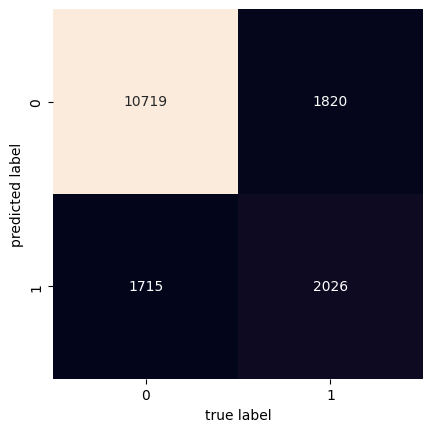

In [189]:

mat = metrics.confusion_matrix(income_test.target, predictions)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [190]:
income.get_category_maps('high_income')

{0: '<=50K', 1: '>50K'}

#### Analise a influência de parâmetros sobre desempenho de árvores de decisão
- parâmetro "tamanho do conjunto de treino"
- parâmetro "número de níveis da árvore.

In [191]:
test_size = 0.2
max_depth = 10

X_train, X_test, y_train, y_test = train_test_split(
    income.data, 
    income.target, 
    random_state=3, 
    test_size=test_size,
)

dtc = DecisionTreeClassifier(
    random_state=1,
    max_depth=max_depth,
    # class_weight="balanced"
)

steps = [("dtc", dtc)]

pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

results = metrics.classification_report(y_test, predictions, zero_division=1)

"""
Conclusões:

    Os testes mostram que a precisão e o recall para a classificação de rendas >50k
    ficam com valores abaixo de 60%, mesmo aumentando max_depth e diminuindo o conjuntto 
    de testes.

    O recall baixo indica que o modelo está ignorando muitos casos de renda alta (>50k),
    classificando-os incorretamente como <=50K.

    A precisão alta da classificação <= 50k em detrimento de >50k indica que por alguma razão 
    supergeneralizando — ou seja, favorecendo a classe majoritária.

Solução:

    Essa situação é típica de datasets desbalanceados, e pode ser amenizada com o uso de técnicas como 
    ajuste de pesos (`class_weight="balanced"`)
"""
print(results)

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4931
           1       0.67      0.57      0.61      1582

    accuracy                           0.83      6513
   macro avg       0.77      0.74      0.75      6513
weighted avg       0.82      0.83      0.82      6513



Utilize a técnica de Random Forest para classificar a variável "high_income" do exercíco anterior.

In [192]:
n_estimators = 100

X_train, X_test, y_train, y_test = train_test_split(
    income.data, income.target, test_size=test_size, random_state=3
)

rfc = RandomForestClassifier(
    random_state=1,
    n_estimators=n_estimators,
    max_depth=max_depth,
    # class_weight="balanced",
)

steps = [("rfc", rfc)]

pipeline = Pipeline(steps)

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)
results = metrics.classification_report(y_test, predictions, zero_division=1)

"""
Conclusões:

    Mesmo problema identificado no exemplo anterior persiste: recall e 
    precisão baixos para a classe >50K.

    Isso evidencia que, mesmo utilizando um modelo mais robusto — como o 
    Random Forest — e aplicando técnicas de balanceamento de classes, os 
    resultados insatisfatórios continuam.
"""
print(results)

              precision    recall  f1-score   support

           0       0.86      0.93      0.90      4931
           1       0.72      0.53      0.61      1582

    accuracy                           0.84      6513
   macro avg       0.79      0.73      0.75      6513
weighted avg       0.83      0.84      0.83      6513

